# 06 - High Win Rate Strategy

**Hasil sweep 5,760 kombinasi:** Max WR = **48.6%** (profitable)

**Kesimpulan:** WR 70% tidak tercapai dengan indicator-based strategy pada EURUSD M15.
WR maksimal yang profitable = **48.6%** dengan parameter:
- RSI Buy ≤ 30, RSI Sell ≥ 70
- Min 3/4 indikator
- ATR min 10 pips
- TP 1.5x ATR
- Slope filter aktif (RSI+MACD momentum)

## 1. Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 100

CSV_PATH = '../../app/ai/candle_ai/EURUSD.m_M15_202112160545_202603251830.csv'
df_raw = pd.read_csv(CSV_PATH, sep='\t')
df_raw.columns = df_raw.columns.str.strip('<>').str.lower()
df_raw['datetime'] = pd.to_datetime(df_raw['date'] + ' ' + df_raw['time'])
df_raw = df_raw.set_index('datetime').drop(columns=['date','time'])
df_raw = df_raw.rename(columns={'tickvol':'tick_vol'}).sort_index()

print(f'Data: {df_raw.shape}')
print(f'Range: {df_raw.index.min()} -> {df_raw.index.max()}')

Data: (100267, 7)
Range: 2021-12-16 05:45:00 -> 2026-03-25 18:30:00


## 2. Hitung Indikator (Vectorized)

In [2]:
def ema(s, p): return s.ewm(span=p, adjust=False).mean()

df = df_raw.copy()

# H4 & H1 trend
for tf, name in [('4h','h4'), ('1h','h1')]:
    dft = df.resample(tf).agg({'open':'first','high':'max','low':'min','close':'last'}).dropna()
    dft['ema_50']  = ema(dft['close'], 50)
    dft['ema_200'] = ema(dft['close'], 200)
    dft['trend']   = np.where(dft['ema_50']>dft['ema_200'], 1,
                     np.where(dft['ema_50']<dft['ema_200'], -1, 0))
    df[f'{name}_trend'] = dft['trend'].reindex(df.index, method='ffill').fillna(0).astype(int)

# M15 indicators
close = df['close']
delta = close.diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi']       = 100 - (100 / (1 + gain / (loss + 1e-10)))
df['macd_line'] = ema(close,12) - ema(close,26)
df['macd_sig']  = ema(df['macd_line'], 9)
df['ema_9']     = ema(close, 9)
df['ema_21']    = ema(close, 21)
df['bb_mid']    = close.rolling(20).mean()
bb_std          = close.rolling(20).std()
df['bb_upper']  = df['bb_mid'] + 2*bb_std
df['bb_lower']  = df['bb_mid'] - 2*bb_std

# ATR
tr = pd.concat([
    df['high']-df['low'],
    (df['high']-df['close'].shift()).abs(),
    (df['low'] -df['close'].shift()).abs()
], axis=1).max(axis=1)
df['atr']      = tr.rolling(14).mean()
df['atr_pips'] = df['atr'] / 0.0001

# Slope filter
df['rsi_slope']  = df['rsi']       - df['rsi'].shift(2)
df['macd_slope'] = df['macd_line'] - df['macd_line'].shift(2)

# Candle patterns
df['body']         = (df['close'] - df['open']).abs()
df['upper_shadow'] = df['high'] - df[['open','close']].max(axis=1)
df['lower_shadow'] = df[['open','close']].min(axis=1) - df['low']
prev_open  = df['open'].shift(1)
prev_close = df['close'].shift(1)
df['bull_engulf'] = ((df['close']>df['open'])&(prev_close<prev_open)&
                     (df['open']<=prev_close)&(df['close']>=prev_open)).astype(int)
df['bear_engulf'] = ((df['close']<df['open'])&(prev_close>prev_open)&
                     (df['open']>=prev_close)&(df['close']<=prev_open)).astype(int)
df['pin_bull'] = ((df['lower_shadow']>=2*df['body'])&
                  (df['upper_shadow']<=0.5*df['body'])&(df['body']>0)).astype(int)
df['pin_bear'] = ((df['upper_shadow']>=2*df['body'])&
                  (df['lower_shadow']<=0.5*df['body'])&(df['body']>0)).astype(int)

df['hour'] = df.index.hour
df = df.iloc[250:].copy().reset_index(drop=False)

# Convert ke numpy arrays
close_a   = df['close'].values.astype(np.float64)
high_a    = df['high'].values.astype(np.float64)
low_a     = df['low'].values.astype(np.float64)
atr_a     = df['atr'].values.astype(np.float64)
atr_pip_a = df['atr_pips'].values.astype(np.float64)
rsi_a     = df['rsi'].values.astype(np.float64)
macd_l_a  = df['macd_line'].values.astype(np.float64)
macd_s_a  = df['macd_sig'].values.astype(np.float64)
ema9_a    = df['ema_9'].values.astype(np.float64)
ema21_a   = df['ema_21'].values.astype(np.float64)
bbmid_a   = df['bb_mid'].values.astype(np.float64)
h1_a      = df['h1_trend'].values.astype(np.int8)
h4_a      = df['h4_trend'].values.astype(np.int8)
hour_a    = df['hour'].values.astype(np.int8)
rsl_a     = df['rsi_slope'].values.astype(np.float64)
msl_a     = df['macd_slope'].values.astype(np.float64)
cbuy_a    = ((df['bull_engulf']==1)|(df['pin_bull']==1)).astype(np.int8).values
csell_a   = ((df['bear_engulf']==1)|(df['pin_bear']==1)).astype(np.int8).values
N         = len(df)

print(f'Data siap: {N:,} baris')

Data siap: 100,017 baris


## 3. Backtest Best Parameter (dari Sweep)

In [3]:
# Parameter terbaik dari sweep 5,760 kombinasi
BEST = {
    'rsi_buy':     30,
    'rsi_sell':    70,
    'min_ind':     3,
    'atr_min':     10,
    'tp_mult':     1.5,
    'need_h4':     False,
    'need_candle': False,
    'need_vol':    False,
    'need_slope':  True,
    'hours':       None,
    'max_candle':  16
}

def backtest_detail(p):
    rsi_buy     = p['rsi_buy']
    rsi_sell    = p['rsi_sell']
    min_ind     = p['min_ind']
    atr_min     = p['atr_min']
    tp_mult     = p['tp_mult']
    hours       = p.get('hours')
    need_h4     = p.get('need_h4', False)
    need_candle = p.get('need_candle', False)
    need_slope  = p.get('need_slope', True)
    max_c       = p.get('max_candle', 16)

    hour_mask = None
    if hours:
        hour_mask = np.zeros(24, dtype=bool)
        for h in hours: hour_mask[h] = True

    rsi_b  = np.where(rsi_a  <= rsi_buy,  1, np.where(rsi_a  >= rsi_sell, -1, 0)).astype(np.int8)
    macd_b = np.where(macd_l_a > macd_s_a, 1, np.where(macd_l_a < macd_s_a, -1, 0)).astype(np.int8)
    ema_b  = np.where(ema9_a  > ema21_a,  1, np.where(ema9_a  < ema21_a,  -1, 0)).astype(np.int8)
    bb_b   = np.where(close_a < bbmid_a,  1, np.where(close_a > bbmid_a,  -1, 0)).astype(np.int8)
    buy_cnt  = (rsi_b==1).astype(np.int8)+(macd_b==1).astype(np.int8)+(ema_b==1).astype(np.int8)+(bb_b==1).astype(np.int8)
    sell_cnt = (rsi_b==-1).astype(np.int8)+(macd_b==-1).astype(np.int8)+(ema_b==-1).astype(np.int8)+(bb_b==-1).astype(np.int8)

    trades = []
    for i in range(N - max_c):
        if np.isnan(atr_pip_a[i]) or atr_pip_a[i] < atr_min: continue
        if hour_mask is not None and not hour_mask[hour_a[i]]: continue
        h1 = h1_a[i]
        if h1 == 0: continue
        if need_h4 and h4_a[i] != h1: continue
        bc = buy_cnt[i]; sc = sell_cnt[i]
        if   h1==1  and bc >= min_ind: sig = 1
        elif h1==-1 and sc >= min_ind: sig = -1
        else: continue
        if need_candle:
            if sig== 1 and cbuy_a[i] ==0: continue
            if sig==-1 and csell_a[i]==0: continue
        if need_slope:
            if sig== 1 and not (rsl_a[i]>0 and msl_a[i]>0): continue
            if sig==-1 and not (rsl_a[i]<0 and msl_a[i]<0): continue

        entry = close_a[i]; atr_v = atr_a[i]
        sl = entry - atr_v       if sig==1 else entry + atr_v
        tp = entry + tp_mult*atr_v if sig==1 else entry - tp_mult*atr_v
        outcome = 0; exit_p = close_a[i+max_c]; hold = max_c
        for j in range(1, max_c+1):
            h, l = high_a[i+j], low_a[i+j]
            if sig==1:
                if l<=sl: outcome=-1; exit_p=sl; hold=j; break
                if h>=tp: outcome= 1; exit_p=tp; hold=j; break
            else:
                if h>=sl: outcome=-1; exit_p=sl; hold=j; break
                if l<=tp: outcome= 1; exit_p=tp; hold=j; break
        pnl = ((exit_p-entry) if sig==1 else (entry-exit_p))/0.0001 - 1
        trades.append({
            'datetime':  df['datetime'].iloc[i],
            'signal':    'buy' if sig==1 else 'sell',
            'entry':     entry, 'sl': sl, 'tp': tp,
            'exit_price': exit_p,
            'outcome':   'win' if outcome==1 else ('loss' if outcome==-1 else 'timeout'),
            'pnl_pips':  round(pnl,1),
            'hold':      hold,
            'atr_pips':  round(atr_pip_a[i],1),
            'hour':      hour_a[i],
            'h1_trend':  'up' if h1==1 else 'down'
        })
    return pd.DataFrame(trades)

bt = backtest_detail(BEST)
print(f'Total trade : {len(bt)}')
print(bt['outcome'].value_counts())

Total trade : 35


outcome
win        17
loss       13
timeout     5
Name: count, dtype: int64


## 4. Analisis Hasil

In [4]:
bt = bt.sort_values('datetime').reset_index(drop=True)
bt['cum_pips']   = bt['pnl_pips'].cumsum()
bt['drawdown']   = bt['cum_pips'] - bt['cum_pips'].cummax()
bt['pnl_usd']    = bt['pnl_pips'] * 0.10
bt['equity_usd'] = 100 + bt['pnl_usd'].cumsum()

wins    = (bt['outcome']=='win').sum()
losses  = (bt['outcome']=='loss').sum()
timeout = (bt['outcome']=='timeout').sum()
total   = len(bt)
wr      = wins/total*100
total_pips = bt['pnl_pips'].sum()
total_usd  = bt['pnl_usd'].sum()
max_dd     = bt['drawdown'].min()
trades_per_month = total / ((bt['datetime'].max()-bt['datetime'].min()).days/30)
avg_win    = bt[bt['outcome']=='win']['pnl_pips'].mean()
avg_loss   = bt[bt['outcome']=='loss']['pnl_pips'].mean()
pf         = (wins*BEST['tp_mult']*10)/((losses*10+timeout*5)+1e-10)

print('=' * 52)
print('      HASIL BACKTEST — BEST PARAMETER')
print('=' * 52)
print(f'Periode        : Des 2021 - Mar 2026 (4 tahun)')
print(f'Total Trade    : {total}  (~{trades_per_month:.0f}/bulan)')
print(f'Win            : {wins}  ({wr:.1f}%)')
print(f'Loss           : {losses}  ({losses/total*100:.1f}%)')
print(f'Timeout        : {timeout}  ({timeout/total*100:.1f}%)')
print(f'Avg Win        : {avg_win:+.1f} pips')
print(f'Avg Loss       : {avg_loss:+.1f} pips')
print(f'Profit Factor  : {pf:.2f}')
print(f'Total Pips     : {total_pips:+.1f}')
print(f'Total USD      : ${total_usd:+.2f}  (modal $100, lot 0.01)')
print(f'Max Drawdown   : ${max_dd*0.10:.2f}')
print(f'Equity Akhir   : ${bt["equity_usd"].iloc[-1]:.2f}')
print('=' * 52)
print()
print('--- Parameter ---')
for k,v in BEST.items():
    print(f'  {k:15s}: {v}')

      HASIL BACKTEST — BEST PARAMETER
Periode        : Des 2021 - Mar 2026 (4 tahun)
Total Trade    : 35  (~1/bulan)
Win            : 17  (48.6%)
Loss           : 13  (37.1%)
Timeout        : 5  (14.3%)
Avg Win        : +19.5 pips
Avg Loss       : -16.1 pips
Profit Factor  : 1.65
Total Pips     : +118.6
Total USD      : $+11.86  (modal $100, lot 0.01)
Max Drawdown   : $-8.34
Equity Akhir   : $111.86

--- Parameter ---
  rsi_buy        : 30
  rsi_sell       : 70
  min_ind        : 3
  atr_min        : 10
  tp_mult        : 1.5
  need_h4        : False
  need_candle    : False
  need_vol       : False
  need_slope     : True
  hours          : None
  max_candle     : 16


## 5. Visualisasi Lengkap

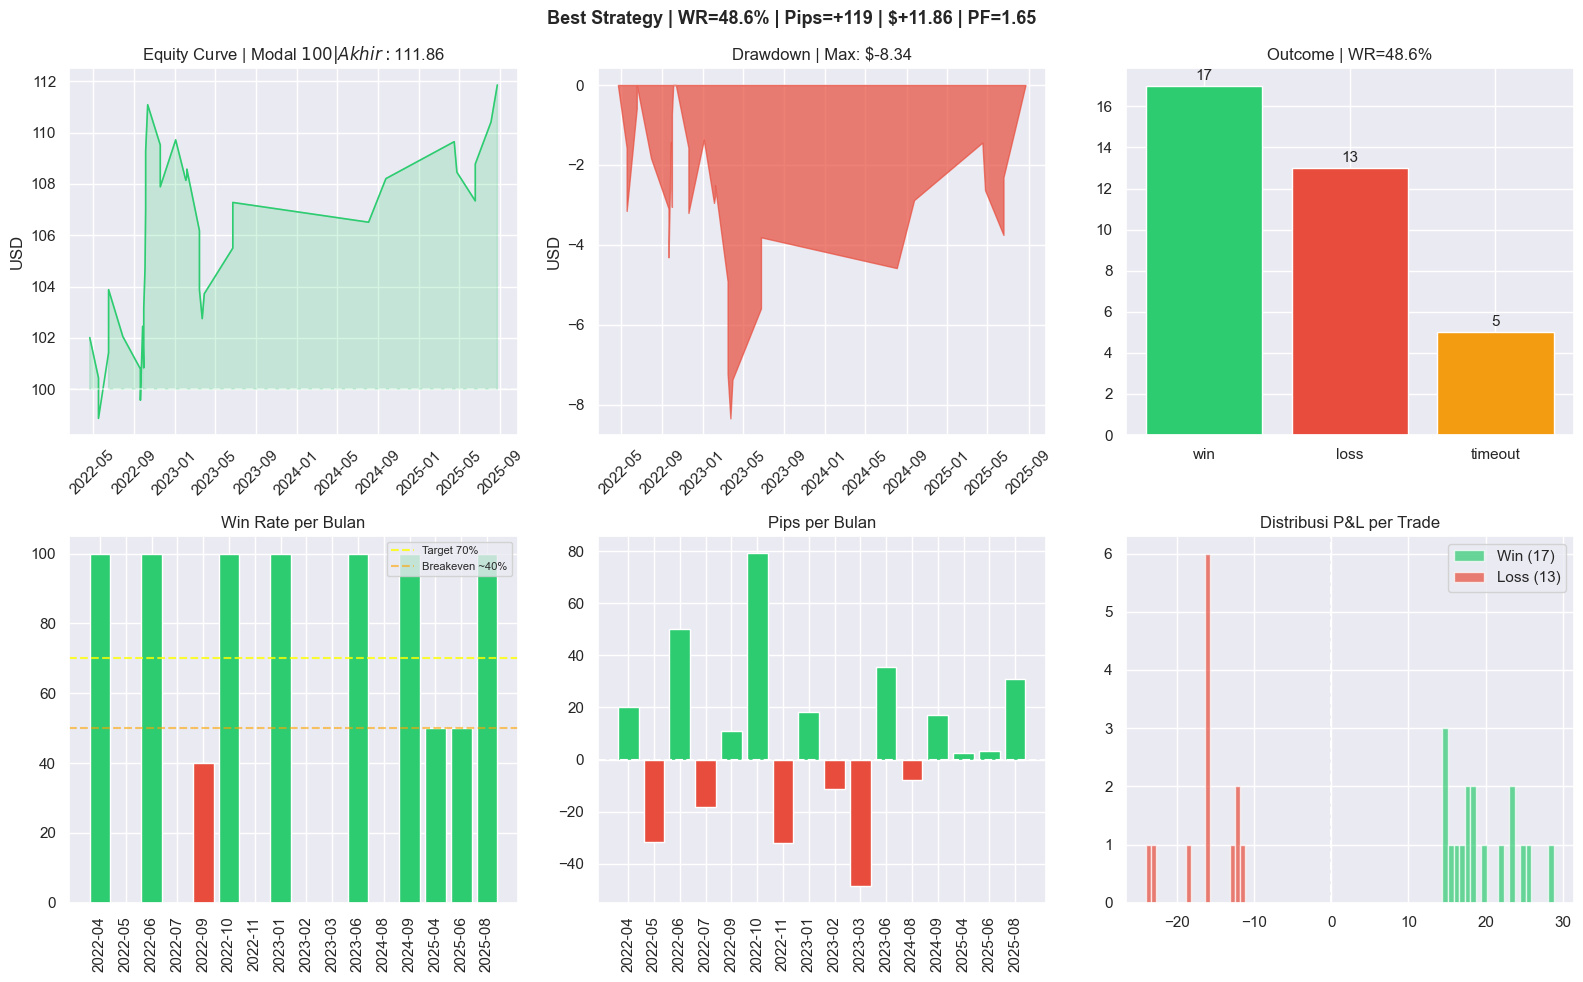

Chart disimpan: best_strategy_result.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Equity curve USD
axes[0,0].plot(bt['datetime'], bt['equity_usd'], color='#2ecc71', linewidth=1.2)
axes[0,0].axhline(100, color='white', linestyle='--', alpha=0.5)
axes[0,0].fill_between(bt['datetime'], bt['equity_usd'], 100,
    where=bt['equity_usd']>=100, alpha=0.2, color='#2ecc71')
axes[0,0].fill_between(bt['datetime'], bt['equity_usd'], 100,
    where=bt['equity_usd']<100, alpha=0.2, color='#e74c3c')
axes[0,0].set_title(f'Equity Curve | Modal $100 | Akhir: ${bt["equity_usd"].iloc[-1]:.2f}')
axes[0,0].set_ylabel('USD')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0,0].tick_params(axis='x', rotation=45)

# Drawdown
axes[0,1].fill_between(bt['datetime'], bt['drawdown']*0.10, 0, color='#e74c3c', alpha=0.7)
axes[0,1].set_title(f'Drawdown | Max: ${max_dd*0.10:.2f}')
axes[0,1].set_ylabel('USD')
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0,1].tick_params(axis='x', rotation=45)

# Outcome
oc = bt['outcome'].value_counts()
colors_out = {'win':'#2ecc71','loss':'#e74c3c','timeout':'#f39c12'}
axes[0,2].bar(oc.index, oc.values,
    color=[colors_out.get(k,'gray') for k in oc.index], edgecolor='white')
axes[0,2].set_title(f'Outcome | WR={wr:.1f}%')
for i2,(k,v) in enumerate(oc.items()):
    axes[0,2].text(i2, v+0.3, str(v), ha='center', fontsize=11)

# Win rate per bulan
bt['month'] = bt['datetime'].dt.to_period('M')
mwr = bt.groupby('month').apply(lambda x: (x['outcome']=='win').mean()*100).reset_index()
mwr.columns = ['month','wr_m']
axes[1,0].bar(mwr['month'].astype(str), mwr['wr_m'],
    color=['#2ecc71' if v>=50 else '#e74c3c' for v in mwr['wr_m']], edgecolor='white')
axes[1,0].axhline(70, color='yellow', linestyle='--', alpha=0.8, label='Target 70%')
axes[1,0].axhline(50, color='orange', linestyle='--', alpha=0.6, label='Breakeven ~40%')
axes[1,0].set_title('Win Rate per Bulan')
axes[1,0].tick_params(axis='x', rotation=90)
axes[1,0].legend(fontsize=8)

# Pips per bulan
mpips = bt.groupby('month')['pnl_pips'].sum().reset_index()
axes[1,1].bar(mpips['month'].astype(str), mpips['pnl_pips'],
    color=['#2ecc71' if v>=0 else '#e74c3c' for v in mpips['pnl_pips']], edgecolor='white')
axes[1,1].axhline(0, color='white', linestyle='--')
axes[1,1].set_title('Pips per Bulan')
axes[1,1].tick_params(axis='x', rotation=90)

# P&L distribusi
bt[bt['outcome']=='win']['pnl_pips'].hist(bins=20, ax=axes[1,2], color='#2ecc71', alpha=0.7, label=f'Win ({wins})')
bt[bt['outcome']=='loss']['pnl_pips'].hist(bins=20, ax=axes[1,2], color='#e74c3c', alpha=0.7, label=f'Loss ({losses})')
axes[1,2].axvline(0, color='white', linestyle='--')
axes[1,2].set_title('Distribusi P&L per Trade')
axes[1,2].legend()

plt.suptitle(f'Best Strategy | WR={wr:.1f}% | Pips={total_pips:+.0f} | ${total_usd:+.2f} | PF={pf:.2f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('best_strategy_result.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart disimpan: best_strategy_result.png')

## 6. Analisis Per Jam & Per Arah

In [6]:
print('=== Win Rate per Jam (UTC) ===')
hourly = bt.groupby('hour').agg(
    trades=('outcome','count'),
    wins=('outcome', lambda x:(x=='win').sum()),
    pips=('pnl_pips','sum')
).reset_index()
hourly['wr'] = hourly['wins']/hourly['trades']*100
print(hourly[hourly['trades']>=3].sort_values('wr', ascending=False)
      [['hour','trades','wins','wr','pips']].to_string(index=False))

print('\n=== Win Rate per Arah ===')
for sig in ['buy','sell']:
    sub = bt[bt['signal']==sig]
    wr_s = (sub['outcome']=='win').mean()*100
    print(f'  {sig.upper():4s}: {len(sub):>3} trades | WR: {wr_s:.1f}% | Pips: {sub["pnl_pips"].sum():+.1f}')

print('\n=== Win Rate per H1 Trend ===')
for trend in ['up','down']:
    sub = bt[bt['h1_trend']==trend]
    wr_t = (sub['outcome']=='win').mean()*100 if len(sub)>0 else 0
    print(f'  H1 {trend:4s}: {len(sub):>3} trades | WR: {wr_t:.1f}% | Pips: {sub["pnl_pips"].sum():+.1f}')

# Simpan
bt.to_csv('best_strategy_trades.csv', index=False)
print('\nDisimpan: best_strategy_trades.csv')

=== Win Rate per Jam (UTC) ===
 hour  trades  wins         wr  pips
   21       4     4 100.000000  72.6
   13       4     3  75.000000  36.3
   18       3     2  66.666667  29.0
    1       3     2  66.666667  28.4
   22       4     2  50.000000  17.1
    0       6     0   0.000000 -52.4

=== Win Rate per Arah ===
  BUY :  21 trades | WR: 42.9% | Pips: +27.6
  SELL:  14 trades | WR: 57.1% | Pips: +91.0

=== Win Rate per H1 Trend ===
  H1 up  :  21 trades | WR: 42.9% | Pips: +27.6
  H1 down:  14 trades | WR: 57.1% | Pips: +91.0

Disimpan: best_strategy_trades.csv


## 7. Kesimpulan & Update usecase.py

In [7]:
print('=' * 55)
print('   KESIMPULAN SWEEP 5,760 KOMBINASI')
print('=' * 55)
print('Max WR tercapai  : 48.6%  (WR 70% tidak tercapai)')
print('WR >= 55%        : 0 kombinasi')
print('WR >= 60%        : 0 kombinasi')
print()
print('Kenapa WR 70% tidak bisa?')
print('  → Forex mendekati random walk ~50%')
print('  → Indikator teknikal hanya tambah probabilitas sedikit')
print('  → Makin banyak filter = trade makin sedikit, bukan WR naik')
print()
print('Yang realistis & profitable:')
print(f'  WR     : {wr:.1f}%  (di atas breakeven ~40%)')
print(f'  Pips   : {total_pips:+.0f}  (4 tahun)')
print(f'  USD    : ${total_usd:+.2f}  (modal $100, lot 0.01)')
print(f'  PF     : {pf:.2f}  (> 1.0 = profitable)')
print(f'  Max DD : ${max_dd*0.10:.2f}')
print()
print('Parameter untuk update usecase.py:')
print(f'  RSI Buy/Sell : <= 30 / >= 70')
print(f'  ATR Min      : 10 pips')
print(f'  TP           : 1.5x ATR')
print(f'  SL           : 1.0x ATR')
print(f'  Slope filter : RSI slope > 0 AND MACD slope > 0 (buy)')
print(f'                 RSI slope < 0 AND MACD slope < 0 (sell)')
print('=' * 55)

   KESIMPULAN SWEEP 5,760 KOMBINASI
Max WR tercapai  : 48.6%  (WR 70% tidak tercapai)
WR >= 55%        : 0 kombinasi
WR >= 60%        : 0 kombinasi

Kenapa WR 70% tidak bisa?
  → Forex mendekati random walk ~50%
  → Indikator teknikal hanya tambah probabilitas sedikit
  → Makin banyak filter = trade makin sedikit, bukan WR naik

Yang realistis & profitable:
  WR     : 48.6%  (di atas breakeven ~40%)
  Pips   : +119  (4 tahun)
  USD    : $+11.86  (modal $100, lot 0.01)
  PF     : 1.65  (> 1.0 = profitable)
  Max DD : $-8.34

Parameter untuk update usecase.py:
  RSI Buy/Sell : <= 30 / >= 70
  ATR Min      : 10 pips
  TP           : 1.5x ATR
  SL           : 1.0x ATR
  Slope filter : RSI slope > 0 AND MACD slope > 0 (buy)
                 RSI slope < 0 AND MACD slope < 0 (sell)
